# AAL3 Labels on Colin27 and ICBM152

This notebook starts from the AAL3 atlas volume (`ROI_MNI_V7_1mm.nii`) and an AAL3 label JSON lookup. It assigns the atlas labels to brain-surface vertices with `TwoSurfaceHeadModel.assign_parcels_via_mni_coords`, plots the result, and optionally saves compact parcel-level TSV summaries at the end.

In [39]:
from pathlib import Path
import colorsys
import json

import cedalion.data
import cedalion.dot
import cedalion.vis.blocks as vbx
import numpy as np
import pandas as pd
import pyvista as pv
from scipy.spatial import KDTree

pv.set_jupyter_backend("static")

In [40]:
aal_files = cedalion.data.get_aal3_atlas_files()
AAL_DIR = aal_files.basedir
AAL_JSON = aal_files.labels_json
AAL_COLIN_NII = aal_files.nifti

# Write generated summary tables to the current working directory.
OUTPUT_DIR = Path(r"C:\Users\mayucel\Documents\CODE\atlas")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SAVE_PARCEL_SUMMARY_TSVS = True
OUT_COLIN_PARCEL_SUMMARY_TSV = OUTPUT_DIR / "aal3_parcel_summary_colin27.tsv"
OUT_ICBM_PARCEL_SUMMARY_TSV = OUTPUT_DIR / "aal3_parcel_summary_icbm152.tsv"

AAL_COLIN_NII


WindowsPath('C:/Users/mayucel/Documents/GitHub/cedalion/src/cedalion/data/atlases/aal3/ROI_MNI_V7_1mm.nii')

## Load AAL3 Label Names

The bundled AAL3 JSON uses the same top-level structure as the Brodmann lookup: metadata plus a `labels` list with `index` and `name`.

In [41]:
with AAL_JSON.open("r", encoding="utf-8") as fin:
    aal_info = json.load(fin)

aal_name = {0: "Background"}
aal_name.update({int(item["index"]): item["name"] for item in aal_info["labels"]})

print(f"Loaded {len(aal_info['labels'])} AAL3 labels from {AAL_JSON.name}.")


Loaded 166 AAL3 labels from aal_labels.json.


## Assign AAL3 Atlas onto Colin27 Surface

AAL3 is assigned to the surface vertices with `TwoSurfaceHeadModel.assign_parcels_via_mni_coords`. The per-vertex labels are kept in memory; only the compact parcel-level TSV summaries are optionally saved at the end.


In [42]:
def vertex_label_dataframe(head_labeled, model, label_col, source_nifti):
    coords_mni = head_labeled.get_brain_mni152_coords().pint.dequantify()
    labels = head_labeled.brain.vertices.coords[label_col].values
    vertex = head_labeled.brain.vertices.label.values
    df = pd.DataFrame({
        "vertex": vertex,
        "model": model,
        "coordinate_mode": "assign_parcels_via_mni_coords",
        "source_nifti": str(source_nifti),
        "mni152_r": coords_mni.values[:, 0],
        "mni152_a": coords_mni.values[:, 1],
        "mni152_s": coords_mni.values[:, 2],
        "aal_name": labels,
    })
    return df


def make_aal_vertex_labels(model, label_nii):
    head = cedalion.dot.get_standard_headmodel(model)
    head_labeled = head.assign_parcels_via_mni_coords(
        "parcel_aal3",
        aal_name,
        label_nii,
        voxel_label_crs="mni305",
        mni_eps=5.0,
    )
    return head_labeled, vertex_label_dataframe(head_labeled, model, "parcel_aal3", label_nii)


head_colin_aal3_raw, df_colin = make_aal_vertex_labels("colin27", AAL_COLIN_NII)

print(
    f"Colin27 AAL3 vertex labels: {len(df_colin)} vertices, "
    f"{df_colin['aal_name'].nunique()} unique labels."
)

Colin27 AAL3 vertex labels: 25000 vertices, 133 unique labels.


In [43]:
def make_label_colors(names):
    unique_names = [name for name in sorted(pd.unique(names)) if name != "Background"]
    colors = {}
    for i, name in enumerate(unique_names):
        # Use saturated, evenly spaced hues so grey is reserved for true background.
        hue = (0.61803398875 * i) % 1.0
        sat = 0.68 + 0.16 * ((i % 3) / 2)
        val = 0.78 + 0.14 * (((i // 3) % 3) / 2)
        colors[name] = [int(round(255 * c)) for c in colorsys.hsv_to_rgb(hue, sat, val)]
    colors["Background"] = [238, 238, 238]
    return colors


aal_colors = make_label_colors(df_colin["aal_name"] )


def colors_for_vertices(df):
    df = df.sort_values("vertex")
    missing_names = sorted(set(df["aal_name"].values) - set(aal_colors))
    if missing_names:
        aal_colors.update(make_label_colors(pd.Series(missing_names)))
    return np.asarray([aal_colors[name] for name in df["aal_name"].values], dtype=np.uint8)


def fill_background_from_nearest_surface_label(df, head, label_col="aal_name"):
    df_filled = df.sort_values("vertex").copy()
    background = df_filled[label_col].eq("Background")
    if not background.any():
        return df_filled

    vertices = head.brain.vertices.pint.dequantify()
    coords = vertices.sel(label=df_filled["vertex"].to_numpy()).values
    labeled = ~background.to_numpy()
    _, nearest = KDTree(coords[labeled]).query(coords[~labeled])

    labeled_rows = df_filled.loc[labeled]
    background_rows = df_filled.index[~labeled]
    nearest_rows = labeled_rows.iloc[nearest]
    df_filled.loc[background_rows, label_col] = nearest_rows[label_col].to_numpy()
    return df_filled


## Plot AAL3 Labels On Colin27

This section shows the AAL3 labels on the Colin27 pial surface, in standard views, and on the inflated cortex.

In [44]:
def camera_for_view(center, view, distance=360):
    cameras = {
        "superior": ([0, 0, distance], [0, 1, 0]),
        "left": ([-distance, 0, 0], [0, 0, 1]),
        "right": ([distance, 0, 0], [0, 0, 1]),
        "anterior": ([0, distance, 0], [0, 0, 1]),
        "posterior": ([0, -distance, 0], [0, 0, 1]),
    }
    position_offset, up = cameras[view]
    return center + np.asarray(position_offset), center, up


def plot_brain_views_grid(head, colors, views=("superior", "left", "right", "anterior", "posterior")):
    brain_center = head.brain.vertices.pint.dequantify().mean("label").values
    plt = pv.Plotter(shape=(2, 3), window_size=(1500, 900))
    positions = [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1)]
    for view, subplot in zip(views, positions):
        plt.subplot(*subplot)
        vbx.plot_surface(plt, head.brain, color=colors)
        plt.add_text(view, font_size=10)
        plt.camera.position, plt.camera.focal_point, plt.camera.up = camera_for_view(brain_center, view)
        plt.reset_camera()
    plt.subplot(1, 2)
    plt.add_text("", font_size=10)
    plt.show()


def plot_surface_views_grid(surface, colors, views=("superior", "left", "right", "anterior", "posterior")):
    surface_center = surface.vertices.pint.dequantify().mean("label").values
    plt = pv.Plotter(shape=(2, 3), window_size=(1500, 900))
    positions = [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1)]
    for view, subplot in zip(views, positions):
        plt.subplot(*subplot)
        vbx.plot_surface(plt, surface, color=colors)
        plt.add_text(view, font_size=10)
        plt.camera.position, plt.camera.focal_point, plt.camera.up = camera_for_view(surface_center, view)
        plt.reset_camera()
    plt.subplot(1, 2)
    plt.add_text("", font_size=10)
    plt.show()



def add_aal3_vertex_coordinate(head, df, coord_name="parcel_aal3"):
    hm = head.copy()
    df_sorted = df.sort_values("vertex")
    hm.brain.vertex_coords[coord_name] = df_sorted["aal_name"].to_numpy()
    return hm


def colors_for_single_aal_roi(df, roi_names, roi_color=(230, 80, 60), background=(210, 210, 210)):
    df_sorted = df.sort_values("vertex")
    available_names = set(df_sorted["aal_name"])
    if isinstance(roi_names, str):
        roi_names = [roi_names]
    roi_names = list(roi_names)

    missing = [name for name in roi_names if name not in available_names]
    if missing:
        suggestions = {
            name: sorted(candidate for candidate in available_names if name.lower() in candidate.lower())[:10]
            for name in missing
        }
        raise ValueError(f"Unknown AAL ROI(s) {missing}. Suggestions: {suggestions}")

    roi_names = set(roi_names)
    return np.asarray(
        [roi_color if name in roi_names else background for name in df_sorted["aal_name"].values],
        dtype=np.uint8,
    )


def plot_single_aal_roi(head, inflated_surface, df, roi_names, model_name):
    target_label = " + ".join(roi_names) if not isinstance(roi_names, str) else roi_names
    target_names = [roi_names] if isinstance(roi_names, str) else list(roi_names)
    single_roi_colors = colors_for_single_aal_roi(df, target_names)
    vertex_count = int(df["aal_name"].isin(target_names).sum())
    print(f"Plotting {target_label} on {model_name} ({vertex_count} vertices).")

    plt = pv.Plotter(shape=(1, 2), window_size=(1200, 500))
    plt.subplot(0, 0)
    plt.add_text(f"{model_name} pial - {target_label}", position="upper_left", font_size=10)
    vbx.plot_surface(plt, head.brain, color=single_roi_colors)

    plt.subplot(0, 1)
    plt.add_text(f"{model_name} inflated - {target_label}", position="upper_left", font_size=10)
    vbx.plot_surface(plt, inflated_surface, color=single_roi_colors)
    plt.show()


Colin27 background vertices: 114 raw -> 0 plotted


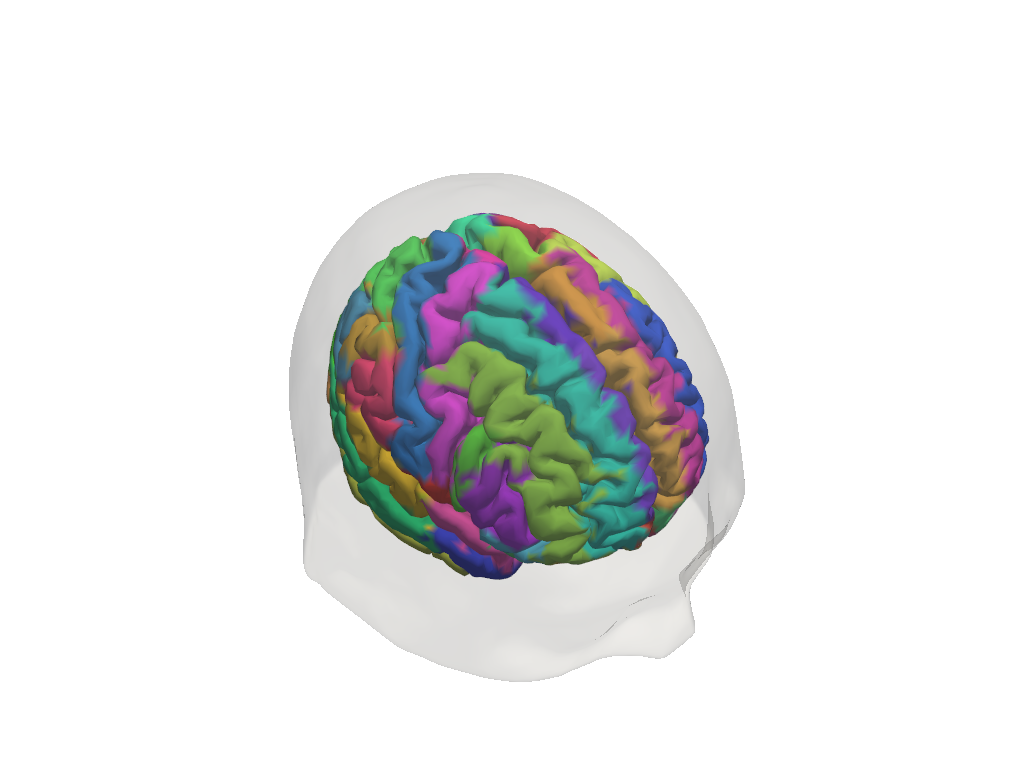

In [45]:
head_colin = cedalion.dot.get_standard_headmodel("colin27")
df_colin_plot = fill_background_from_nearest_surface_label(df_colin, head_colin)
print(
    "Colin27 background vertices:",
    int(df_colin["aal_name"].eq("Background").sum()),
    "raw ->",
    int(df_colin_plot["aal_name"].eq("Background").sum()),
    "plotted",
)
colors_colin = colors_for_vertices(df_colin_plot)

plt = pv.Plotter()
vbx.plot_surface(plt, head_colin.scalp, color="w", opacity=.2)
vbx.plot_surface(plt, head_colin.brain, color=colors_colin)
plt.show()

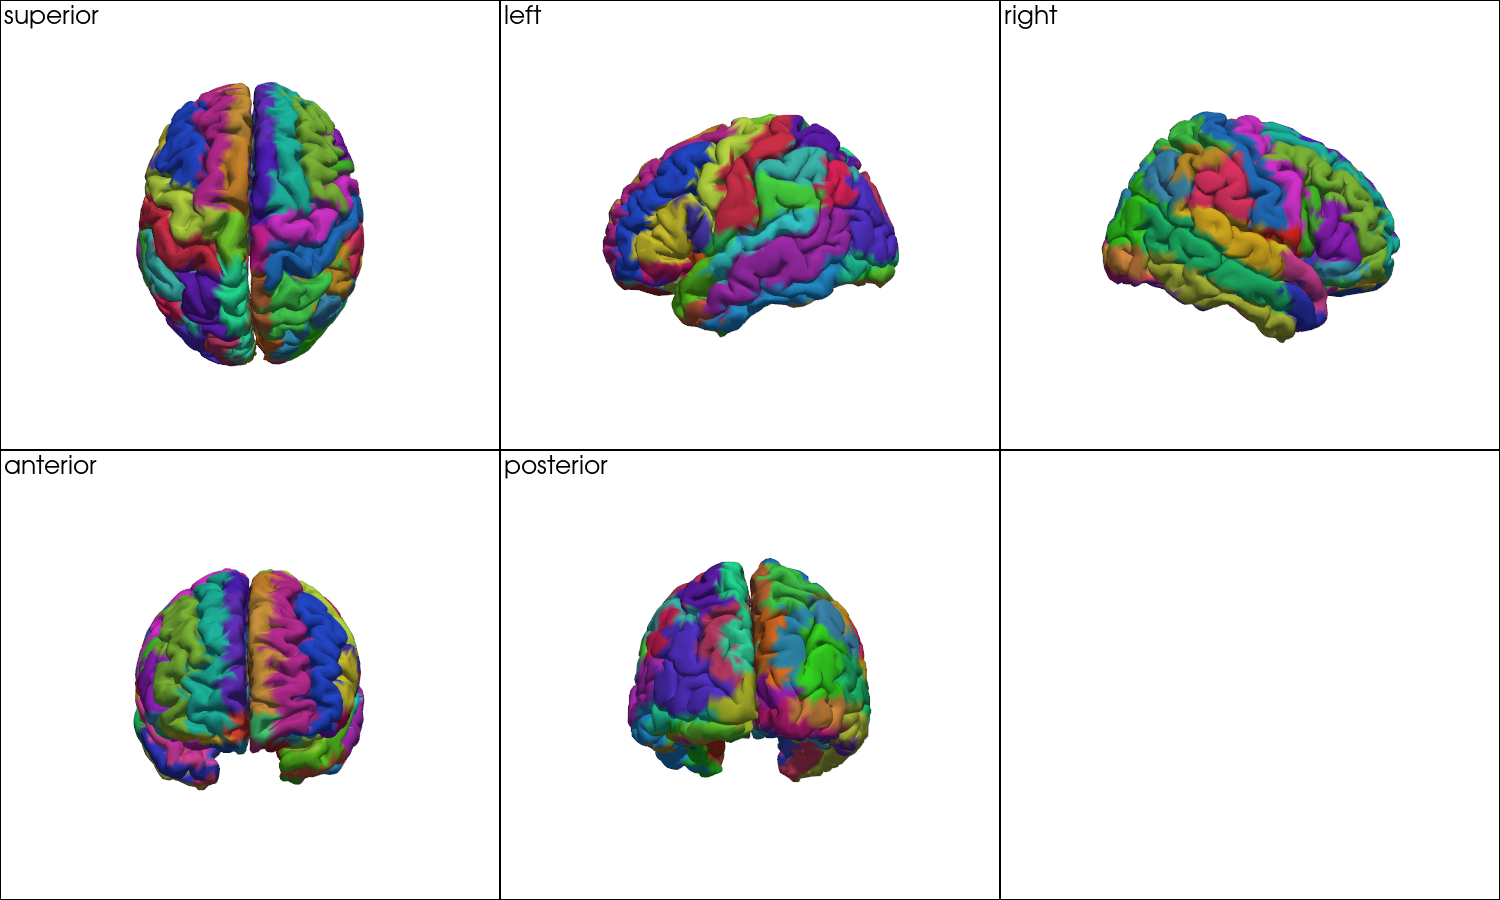

In [46]:
plot_brain_views_grid(head_colin, colors_colin)

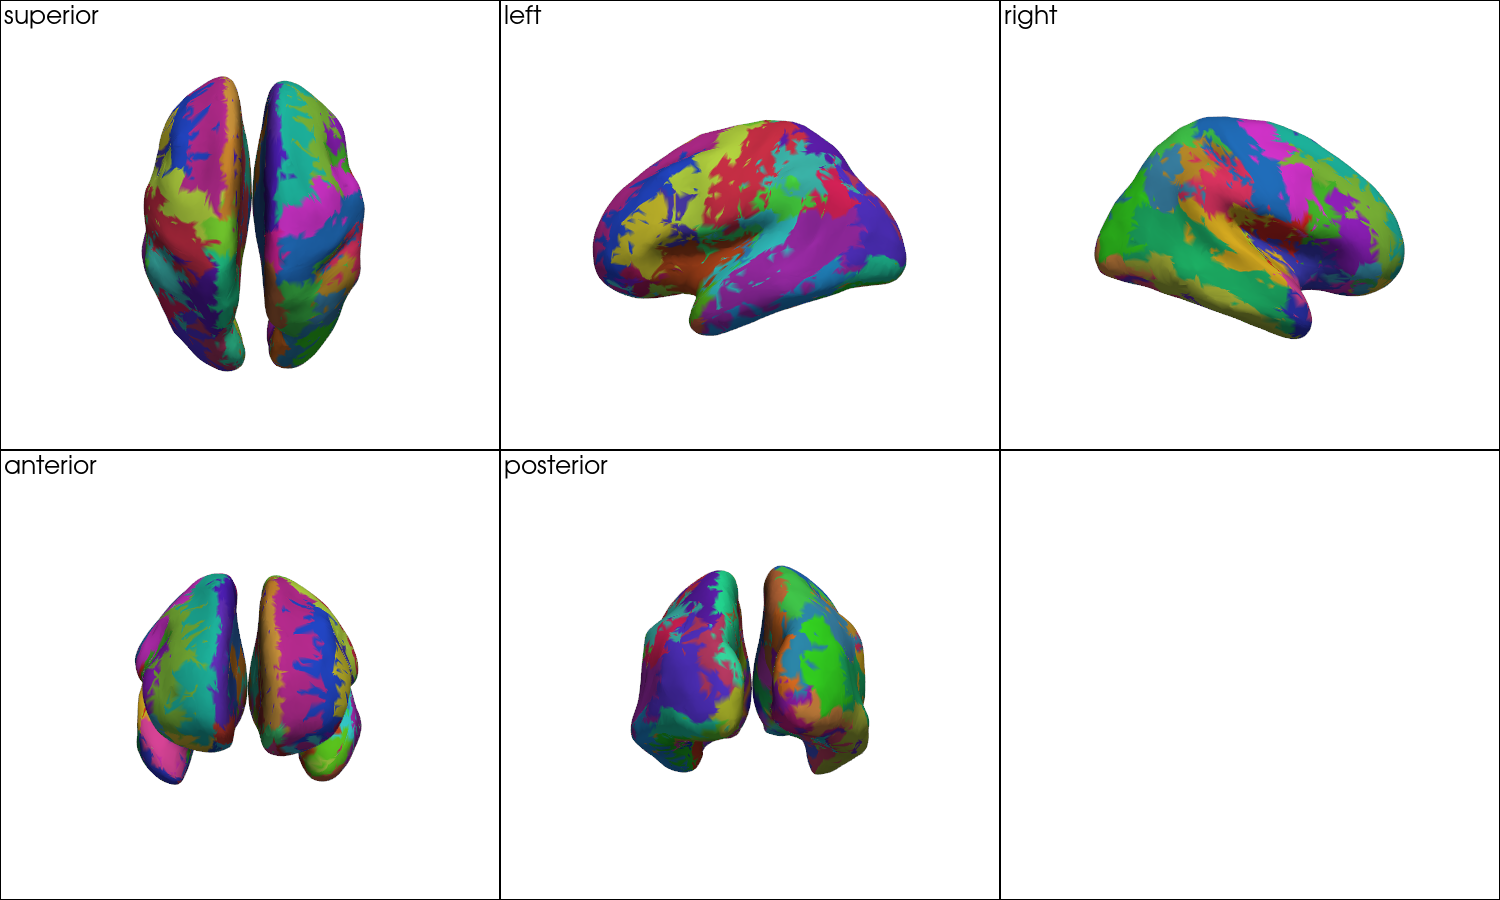

In [47]:
infl_colin = cedalion.dot.get_inflated_cortex_surface("colin27")
plot_surface_views_grid(infl_colin, colors_colin)

## Colin27 Brain Vertices with AAL3 Coordinate

This mirrors the `assign_parcels_via_mni_coords` example output: the AAL3 label is added as a vertex coordinate, then the xarray `DataArray` is displayed directly.


In [48]:
head_colin_aal3 = add_aal3_vertex_coordinate(head_colin, df_colin_plot)
head_colin_aal3.brain.vertices


Magnitude,[[82.522325 19.841515 68.313221] [83.516588 20.319351 65.886337] [78.524571 20.543388 63.648142] ... [127.025612 152.660339 99.546274] [96.280465 105.252083 86.734898] [127.619801 34.463676 60.37505]]
Units,dimensionless


## Highlight an ROI On Colin27

This example highlights a selected AAL3 ROI on the Colin27 pial and inflated cortex.

Plotting Frontal_Inf_Oper_R + Frontal_Inf_Tri_R on colin27 (534 vertices).


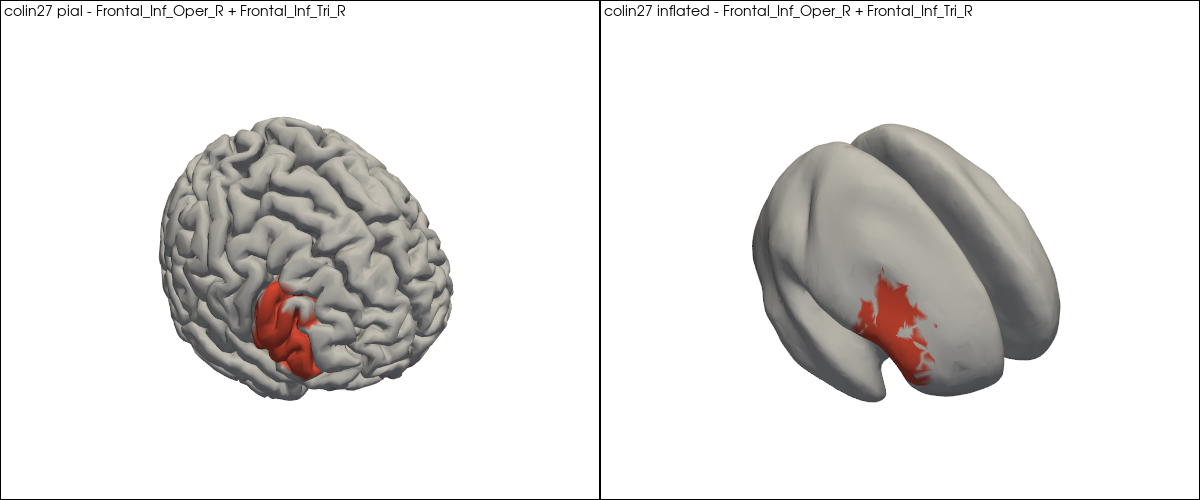

In [49]:
target_aal = ["Frontal_Inf_Oper_R", "Frontal_Inf_Tri_R"]
plot_single_aal_roi(head_colin, infl_colin, df_colin_plot, target_aal, "colin27")

## Assign AAL3 Atlas onto ICBM152 Surface

The AAL3 atlas is assigned directly to ICBM152 with `assign_parcels_via_mni_coords`, using the same label mapping as Colin27.

In [50]:
def transfer_aal_by_nearest_mni152(df_source, source_head, target_head, target_model):
    source_coords = source_head.get_brain_mni152_coords().values
    target_coords = target_head.get_brain_mni152_coords().values
    source_labels = df_source.sort_values("vertex")[["aal_name"]].reset_index(drop=True)

    dist, nearest = KDTree(source_coords).query(target_coords)
    out = pd.DataFrame({
        "vertex": target_head.brain.vertices.label.values,
        "model": target_model,
        "coordinate_mode": "nearest_mni152_surface_from_colin27",
        "distance_to_colin_vertex_mm": dist,
        "aal_name": source_labels.iloc[nearest]["aal_name"].to_numpy(),
    })
    return out


In [51]:
head_icbm = cedalion.dot.get_standard_headmodel("icbm152")

head_icbm_aal3_raw, df_icbm_surface_nearest = make_aal_vertex_labels("icbm152", AAL_COLIN_NII)
df_icbm_surface_plot = fill_background_from_nearest_surface_label(df_icbm_surface_nearest, head_icbm)
print(
    "ICBM152 background vertices:",
    int(df_icbm_surface_nearest["aal_name"].eq("Background").sum()),
    "raw ->",
    int(df_icbm_surface_plot["aal_name"].eq("Background").sum()),
    "plotted",
)
colors_icbm_surface = colors_for_vertices(df_icbm_surface_plot)

print(
    f"ICBM152 AAL3 vertex labels: {len(df_icbm_surface_nearest)} vertices, "
    f"{df_icbm_surface_nearest['aal_name'].nunique()} unique labels."
)

ICBM152 background vertices: 179 raw -> 0 plotted
ICBM152 AAL3 vertex labels: 25000 vertices, 127 unique labels.


## Plot AAL3 Labels On ICBM152

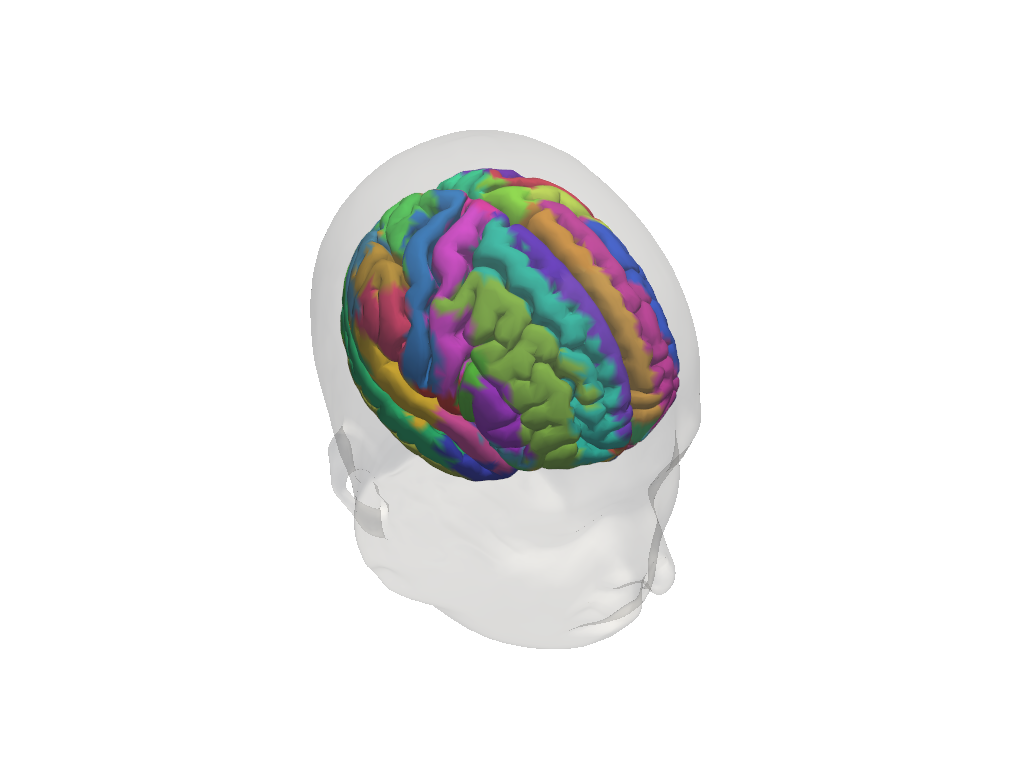

In [52]:
plt = pv.Plotter()
vbx.plot_surface(plt, head_icbm.scalp, color="w", opacity=.2)
vbx.plot_surface(plt, head_icbm.brain, color=colors_icbm_surface)
plt.show()

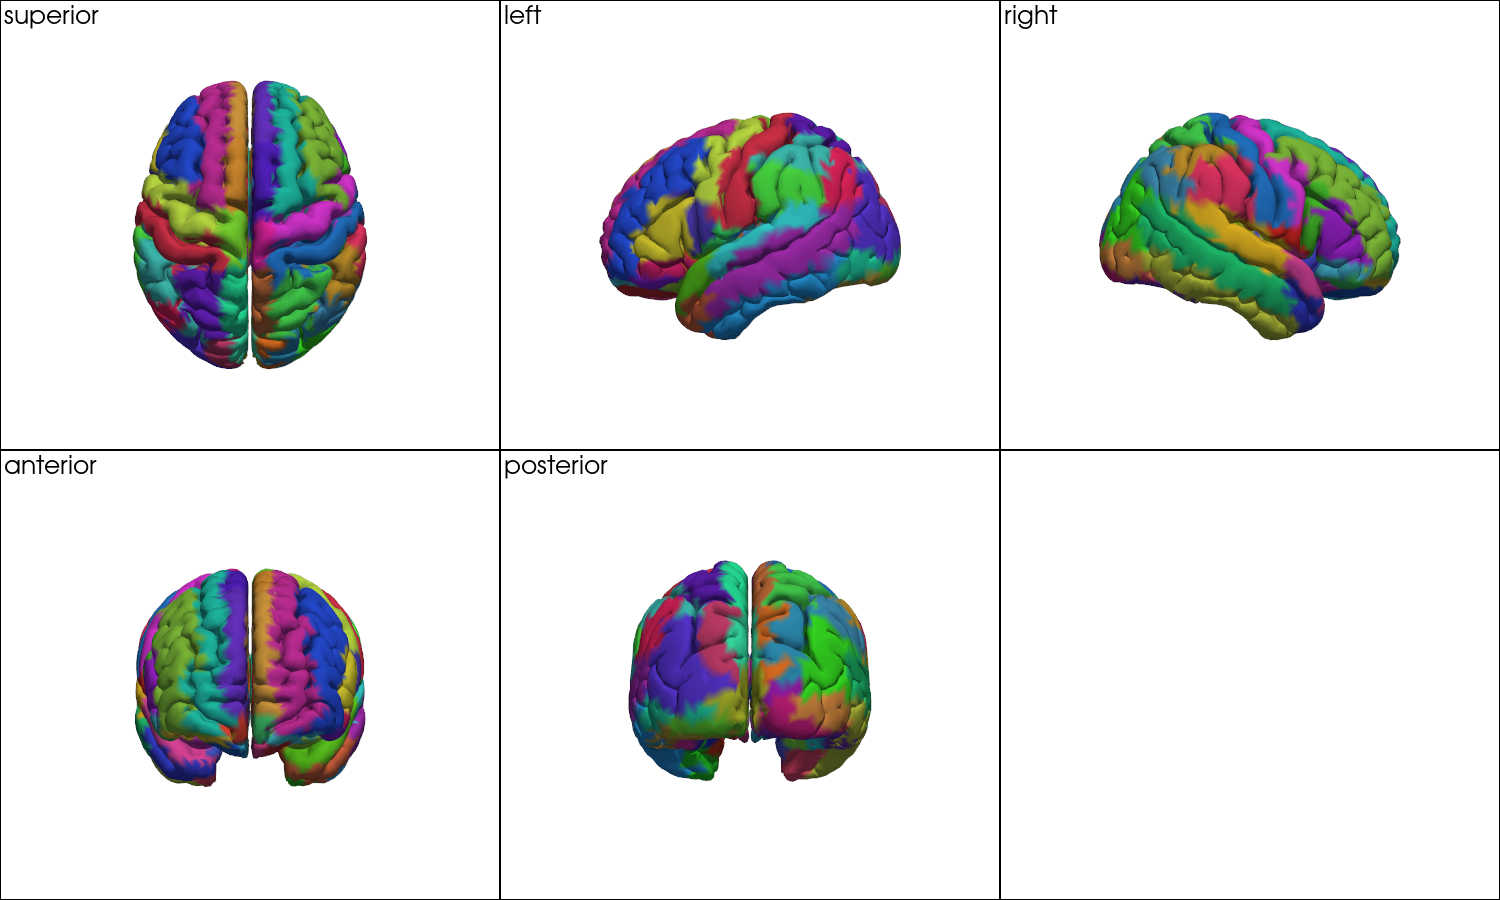

In [53]:
plot_brain_views_grid(head_icbm, colors_icbm_surface)

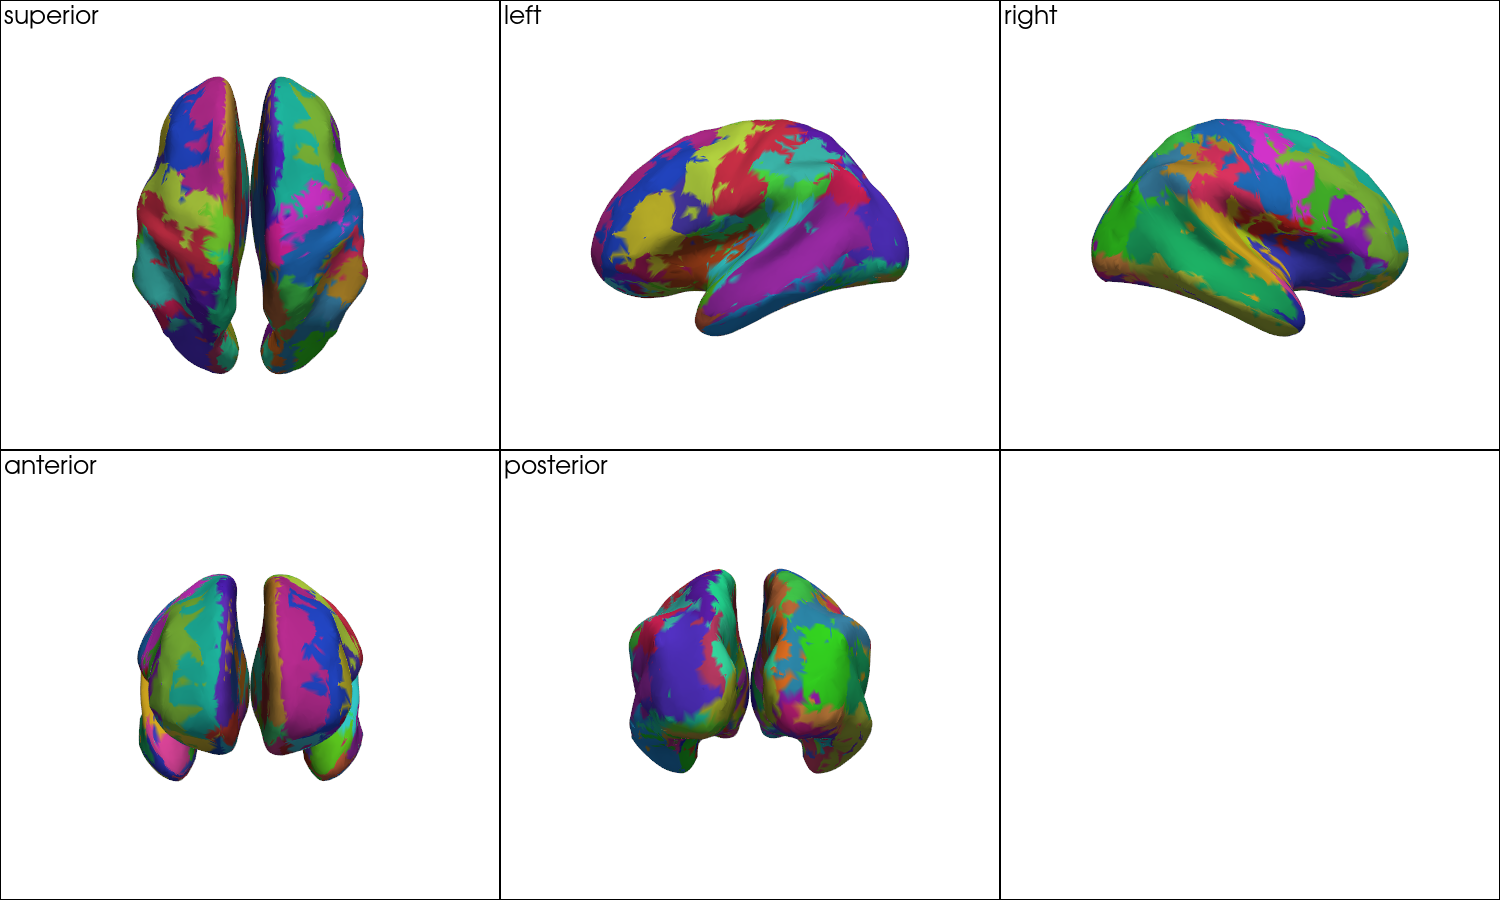

In [54]:
infl_icbm = cedalion.dot.get_inflated_cortex_surface("icbm152")
plot_surface_views_grid(infl_icbm, colors_icbm_surface)

## ICBM152 Brain Vertices with AAL3 Coordinate

The ICBM152 labels are attached as the same xarray-style vertex coordinate using `assign_parcels_via_mni_coords`.


In [55]:
head_icbm_aal3 = add_aal3_vertex_coordinate(head_icbm, df_icbm_surface_plot)
head_icbm_aal3.brain.vertices


Magnitude,[[81.244216 26.627602 150.621031] [81.577181 27.302513 157.143576] [77.826448 27.459724 154.566914] ... [118.580717 84.619659 208.0373] [143.100407 63.906384 138.08789] [133.577629 151.8062 150.919106]]
Units,dimensionless


## Highlight an ROI On ICBM152

This example highlights the same AAL3 ROI on the ICBM152 pial and inflated cortex.

Plotting Frontal_Inf_Oper_R + Frontal_Inf_Tri_R on icbm152 (456 vertices).


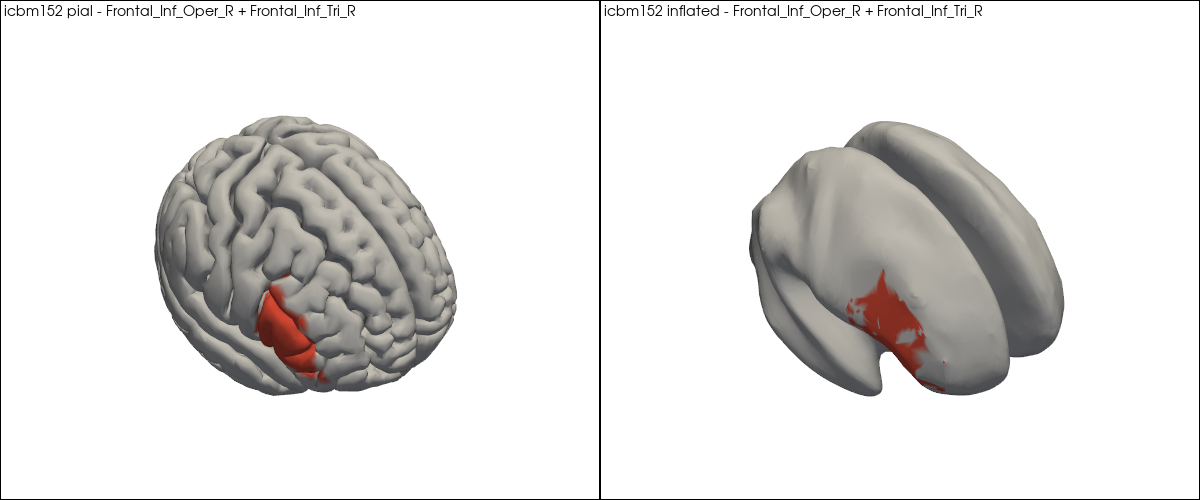

In [56]:
plot_single_aal_roi(head_icbm, infl_icbm, df_icbm_surface_plot, target_aal, "icbm152")

## Parcel-Level Summary Table TSVs

These compact tables have one row per existing head-model parcel, not one row per surface vertex. Medial-wall/background parcels are excluded by default because they are not real cortical parcels. The atlas label is summarized from the xarray vertex coordinate by taking the dominant label inside each parcel and keeping the vertex count/fraction.


In [57]:
def parcel_summary_from_vertex_coordinate(head_labeled, atlas_coord, model, exclude_medial_wall=True):
    vertices = head_labeled.brain.vertices
    coords = vertices.coords
    mni152 = head_labeled.get_brain_mni152_coords().pint.dequantify().values

    df = pd.DataFrame({
        "vertex": vertices.label.values,
        "parcel": coords["parcel"].values,
        "atlas_label": coords[atlas_coord].values,
        "mni152_r": mni152[:, 0],
        "mni152_a": mni152[:, 1],
        "mni152_s": mni152[:, 2],
    })
    if "fsaverage_vertex" in coords:
        df["fsaverage_vertex"] = coords["fsaverage_vertex"].values
    elif "fsaverage_vertex_id" in coords:
        df["fsaverage_vertex"] = coords["fsaverage_vertex_id"].values
    else:
        df["fsaverage_vertex"] = pd.NA

    df["parcel"] = df["parcel"].astype(str)
    df = df[df["parcel"] != ""]

    if exclude_medial_wall:
        medial_wall = df["parcel"].str.contains("Background|Medial_Wall", case=False, na=False)
        df = df[~medial_wall]

    counts = (
        df.groupby(["parcel", "atlas_label"], dropna=False)
        .size()
        .reset_index(name="matching_vertices")
    )
    parcel_totals = df.groupby("parcel").size().rename("parcel_vertices").reset_index()
    summary = counts.merge(parcel_totals, on="parcel", how="left")
    summary["fraction_of_parcel"] = summary["matching_vertices"] / summary["parcel_vertices"]
    summary = summary.sort_values(
        ["parcel", "matching_vertices", "atlas_label"], ascending=[True, False, True]
    ).drop_duplicates("parcel")

    representative = (
        df.sort_values("vertex")
        .drop_duplicates(["parcel", "atlas_label"])
        [["parcel", "atlas_label", "vertex", "fsaverage_vertex", "mni152_r", "mni152_a", "mni152_s"]]
    )
    summary = summary.merge(representative, on=["parcel", "atlas_label"], how="left")
    summary.insert(0, "model", model)
    return summary[[
        "model", "parcel", "atlas_label",
        "vertex", "fsaverage_vertex", "mni152_r", "mni152_a", "mni152_s",
        "matching_vertices", "parcel_vertices", "fraction_of_parcel"
    ]]


EXCLUDE_MEDIAL_WALL_PARCELS = True

aal3_colin_parcel_summary = parcel_summary_from_vertex_coordinate(
    head_colin_aal3, "parcel_aal3", "colin27", EXCLUDE_MEDIAL_WALL_PARCELS
)
aal3_icbm_parcel_summary = parcel_summary_from_vertex_coordinate(
    head_icbm_aal3, "parcel_aal3", "icbm152", EXCLUDE_MEDIAL_WALL_PARCELS
)

# Change this to True to write the compact parcel-level TSV files from this bottom cell.
SAVE_PARCEL_SUMMARY_TSVS = True
OUT_COLIN_PARCEL_SUMMARY_TSV = OUTPUT_DIR / "aal3_parcel_summary_colin27.tsv"
OUT_ICBM_PARCEL_SUMMARY_TSV = OUTPUT_DIR / "aal3_parcel_summary_icbm152.tsv"

if SAVE_PARCEL_SUMMARY_TSVS:
    aal3_colin_parcel_summary.to_csv(OUT_COLIN_PARCEL_SUMMARY_TSV, sep="\t", index=False)
    aal3_icbm_parcel_summary.to_csv(OUT_ICBM_PARCEL_SUMMARY_TSV, sep="\t", index=False)
    print(f"Saved {len(aal3_colin_parcel_summary)} Colin27 parcel rows to {OUT_COLIN_PARCEL_SUMMARY_TSV}")
    print(f"Saved {len(aal3_icbm_parcel_summary)} ICBM152 parcel rows to {OUT_ICBM_PARCEL_SUMMARY_TSV}")
else:
    print(f"Optional save is off. Colin27 parcel summary has {len(aal3_colin_parcel_summary)} rows.")
    print(f"Optional save is off. ICBM152 parcel summary has {len(aal3_icbm_parcel_summary)} rows.")

pd.concat([aal3_colin_parcel_summary, aal3_icbm_parcel_summary], ignore_index=True).head()


Saved 600 Colin27 parcel rows to C:\Users\mayucel\Documents\CODE\atlas\aal3_parcel_summary_colin27.tsv
Saved 600 ICBM152 parcel rows to C:\Users\mayucel\Documents\CODE\atlas\aal3_parcel_summary_icbm152.tsv


,model,parcel,atlas_label,vertex,fsaverage_vertex,mni152_r,mni152_a,mni152_s,matching_vertices,parcel_vertices,fraction_of_parcel
0,colin27,ContA_Cingm_1_LH,Cingulate_Mid_L,5953,81987,-3.695,-8.988,33.489,12,12,1.000000
1,colin27,ContA_Cingm_1_RH,Cingulate_Mid_R,18590,250973,5.049,-6.508,33.139,10,15,0.666667
2,colin27,ContA_IPS_1_LH,Occipital_Mid_L,1249,16617,-28.384,-72.183,42.951,9,19,0.473684
3,colin27,ContA_IPS_1_RH,Occipital_Sup_R,13940,185407,33.101,-67.848,50.827,7,20,0.350000
4,colin27,ContA_IPS_2_LH,SupraMarginal_L,3953,51685,-62.581,-36.589,38.899,16,25,0.640000
